In [8]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage,SystemMessage
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

from pydantic import BaseModel,Field
from dotenv import load_dotenv
from typing import Annotated,TypedDict,Literal,List
import operator

from langgraph.graph import StateGraph,START,END

load_dotenv()

True

# Tweet Agent

In [50]:
class EvaluationStructure(BaseModel):
    model_output:Literal['Approved','NeedImprovement']=Field(description='check if this tweet is as per users requirement or needs any advancements')
    feedback: str = Field(..., description="feedback for the tweet.")

In [51]:
tweet_generator_model=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')
tweet_evaluator_model=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite').with_structured_output(schema=EvaluationStructure)
tweet_optimizer_model=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

In [52]:
class TweetState(TypedDict):
    topic:str
    generated_tweet:Annotated[List[str],operator.add]
    evaluation:Annotated[List[Literal['Approved','NeedImprovement']],operator.add]
    iterations:int
    feedback_history: Annotated[list[str], operator.add]

In [53]:
def tweet_generator(state: TweetState):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
            Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

            Rules:
            - Do NOT use question-answer format.
            - Max 280 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
            """)
    ]

    response = tweet_generator_model.invoke(messages).content

    return {'generated_tweet': [response]}


def tweet_evaluator(state: TweetState):
    latest_tweet = state['generated_tweet'][-1]

    messages = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic."),
        HumanMessage(content=f"""
        Evaluate this tweet:

        "{latest_tweet}"

        Return:
        - model_output: Approved or NeedImprovement
        - feedback: explanation
        """)
    ]

    response = tweet_evaluator_model.invoke(messages)

    return {
        'evaluation': [response.model_output],
        'feedback_history': [response.feedback]
    }


def tweet_optimizer(state: TweetState):
    latest_tweet = state['generated_tweet'][-1]
    latest_feedback = state['feedback_history'][-1]

    messages = [
        SystemMessage(content="You improve tweets."),
        HumanMessage(content=f"""
        Improve this tweet:

        Tweet: {latest_tweet}
        Feedback: {latest_feedback}

        Keep it short, funny, viral.
        """)
    ]

    response = tweet_optimizer_model.invoke(messages).content

    return {
        'generated_tweet': [response],
        'iterations': state['iterations'] + 1
    }

def routing_tweet(state: TweetState):
    latest_eval = state['evaluation'][-1]

    if latest_eval == 'Approved' or state['iterations'] >= 5:
        return 'Approved'
    else:
        return 'NeedImprovement'

In [56]:
graph=StateGraph(state_schema=TweetState)

graph.add_node('tweet_generator',tweet_generator)
graph.add_node('tweet_evaluator',tweet_evaluator)


graph.add_edge(start_key=START,end_key='tweet_generator')
graph.add_edge(start_key='tweet_generator',end_key='tweet_evaluator')
graph.add_conditional_edges(source='tweet_evaluator',path=routing_tweet,path_map={
    'Approved':END,
    'NeedImprovement':'tweet_generator'
})



workflow=graph.compile()

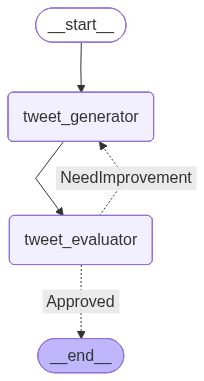

In [57]:
workflow

In [58]:
graph=StateGraph(state_schema=TweetState)

graph.add_node('tweet_generator',tweet_generator)
graph.add_node('tweet_evaluator',tweet_evaluator)
graph.add_node('tweet_optimizer',tweet_optimizer)


graph.add_edge(start_key=START,end_key='tweet_generator')
graph.add_edge(start_key='tweet_generator',end_key='tweet_evaluator')
graph.add_conditional_edges(source='tweet_evaluator',path=routing_tweet,path_map={
    'Approved':END,
    'NeedImprovement':'tweet_optimizer'
})
graph.add_edge(start_key='tweet_optimizer',end_key='tweet_evaluator')


workflow=graph.compile()

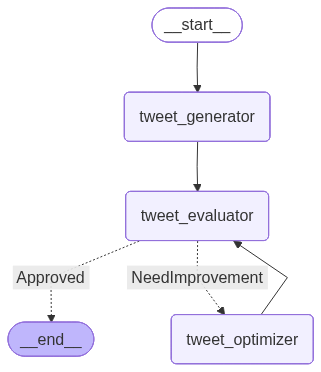

In [59]:
workflow

In [63]:
initial_state = {
    "topic": "srhbergb fg fgds dfg dfg sg fdg",
    "iterations": 1,
}
result = workflow.invoke(initial_state)

In [64]:
result

{'topic': 'srhbergb fg fgds dfg dfg sg fdg',
 'generated_tweet': ['My brain trying to decipher "srhbergb fg fgds dfg dfg sg fdg" is like me trying to assemble IKEA furniture without the instructions. Pretty sure I\'m just gonna end up with a weird, wobbly abstract art piece and a lot of leftover screws. #Mondays #WhatIsThis #SendHelp'],
 'evaluation': ['Approved'],
 'iterations': 1,
 'feedback_history': ['The tweet humorously compares the incomprehensible text to the frustrating experience of assembling IKEA furniture. The hashtags are relevant and add to the overall tone. No improvements are needed.']}